# Esemble Learning

***Ensemble Learning*** adalah teknik dalam *machine learning* yang **menggabungkan beberapa model** individu untuk menghasilkan satu prediksi akhir yang lebih akurat, stabil, dan andal.

Prinsip dasarnya sederhana: daripada mengandalkan "pendapat" dari satu model saja, kita meminta "pendapat" dari sebuah tim model. Keputusan kolektif dari tim ini cenderung jauh lebih baik daripada keputusan individu manapun. 🤝

Tujuan utama dari Ensemble Learning adalah untuk:
* **Meningkatkan Akurasi:** Mengurangi kesalahan prediksi secara keseluruhan.
* **Meningkatkan Stabilitas:** Membuat model lebih tangguh dan konsisten terhadap variasi data.
* **Mengurangi *Overfitting*:** Mencegah model menjadi terlalu "hafal" pada data latih sehingga performanya tetap baik pada data baru yang belum pernah dilihat.

---
## Analogi Sederhana

Bayangkan Anda ingin membuat keputusan finansial yang penting. Anda bisa:
1.  **Bertanya pada satu penasihat keuangan.** Ini seperti menggunakan satu model. Mungkin dia sangat ahli, tapi mungkin juga dia memiliki bias atau melewatkan sesuatu.
2.  **Bertanya pada tim penasihat keuangan** yang terdiri dari beberapa ahli dengan latar belakang berbeda. Anda kemudian mengambil keputusan berdasarkan suara mayoritas atau rata-rata dari saran mereka. Ini adalah pendekatan *Ensemble Learning*. Keputusan yang dihasilkan kemungkinan besar akan lebih seimbang dan tidak terlalu berisiko.

---
## Jenis-Jenis Metode Ensemble
Ada beberapa pendekatan populer dalam Ensemble Learning, yang paling umum adalah:

### 1. Bagging (Bootstrap Aggregating)
Metode ini melatih beberapa model (biasanya dari jenis yang sama, misal *Decision Tree*) secara **paralel**. Setiap model dilatih pada sampel data yang berbeda, yang diambil secara acak dengan penggantian dari dataset utama. Hasil akhir didapatkan dengan cara *voting* (suara mayoritas) untuk klasifikasi atau rata-rata untuk regresi.

* **Tujuan Utama:** Mengurangi varians (membuat model lebih stabil).
* **Contoh Algoritma Populer:** **Random Forest**.



### 2. Boosting
Berbeda dengan Bagging, metode Boosting melatih model secara **berurutan (sekuensial)**. Setiap model baru dibuat untuk **memperbaiki kesalahan** dari model sebelumnya. Model akan lebih fokus pada data yang salah diprediksi oleh model sebelumnya, seolah-olah "belajar dari kesalahan" secara bertahap.

* **Tujuan Utama:** Mengurangi bias (meningkatkan akurasi).
* **Contoh Algoritma Populer:** **AdaBoost**, **Gradient Boosting**, dan **XGBoost**.



### 3. Stacking (Stacked Generalization)
Metode ini menggunakan pendekatan yang sedikit berbeda. Stacking melatih beberapa model yang berbeda (*heterogeneous models*), lalu menggunakan satu "meta-model" atau "model manajer" untuk **mempelajari cara terbaik menggabungkan prediksi** dari model-model dasar tersebut. Meta-model ini dilatih berdasarkan *output* dari model-model di bawahnya.

* **Tujuan Utama:** Memanfaatkan kekuatan dari berbagai jenis model yang berbeda untuk mendapatkan performa terbaik.
* **Contoh:** Menggabungkan output dari *Support Vector Machine (SVM)*, *K-Nearest Neighbors (KNN)*, dan *Random Forest*, lalu menggunakan *Logistic Regression* sebagai meta-model untuk membuat prediksi akhir.

---
## Kapan Sebaiknya Menggunakan Ensemble Learning?

Anda sebaiknya mempertimbangkan Ensemble Learning ketika:
* Anda ingin **akurasi setinggi mungkin** dan rela mengorbankan sedikit kecepatan komputasi.
* Model tunggal yang Anda gunakan cenderung mengalami *overfitting*.
* Anda menghadapi masalah yang kompleks di mana tidak ada satu pun model yang unggul secara signifikan.
* Anda berpartisipasi dalam kompetisi *data science* (metode ini sangat populer dan sering menjadi kunci kemenangan).

## Menampilkan data yang diambil dari UC Machine Learning

Langkah pertama dalam memahami data kami mengambi data dari https://archive.ics.uci.edu/dataset/222/bank+marketing kemudian menariknya dengan menggunakan import dengan python.

In [ ]:
!pip install ucimlrepo
!pip install imbalanced-learn
!pip install -U imbalanced-learn scikit-learn

In [ ]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
from tabulate import tabulate # Impor library tabulate

# 1. Mengambil data (kode dari sebelumnya)
bank_marketing = fetch_ucirepo(id=222)
X = bank_marketing.data.features
y = bank_marketing.data.targets
df = pd.concat([X, y], axis=1)

# 2. Mengambil 3 baris pertama dan 3 baris terakhir (agar tidak terlalu panjang)
head = df.head(5)
tail = df.tail(5)

# 3. Membuat DataFrame pemisah
# Kita isi dengan '...' agar sesuai contoh
separator_row = pd.DataFrame([['...'] * len(df.columns)], columns=df.columns)

# 4. Menggabungkan head, pemisah, dan tail
final_table_df = pd.concat([head, separator_row, tail])

# 5. Menampilkan hasil menggunakan tabulate
# 'psql' adalah format yang paling mirip dengan contoh Anda
# 'headers="keys"' akan menggunakan nama kolom dari DataFrame
print(tabulate(final_table_df, headers='keys', tablefmt='psql', showindex=True))

+-------+-------+--------------+-----------+-------------+-----------+-----------+-----------+--------+-----------+---------------+---------+------------+------------+---------+------------+------------+-----+
|       | age   | job          | marital   | education   | default   | balance   | housing   | loan   | contact   | day_of_week   | month   | duration   | campaign   | pdays   | previous   | poutcome   | y   |
|-------+-------+--------------+-----------+-------------+-----------+-----------+-----------+--------+-----------+---------------+---------+------------+------------+---------+------------+------------+-----|
|     0 | 58    | management   | married   | tertiary    | no        | 2143      | yes       | no     | nan       | 5             | may     | 261        | 1          | -1      | 0          | nan        | no  |
|     1 | 44    | technician   | single    | secondary   | no        | 29        | yes       | no     | nan       | 5             | may     | 151        | 1    

## Visualisasi data dengan Menggunakan PCA

karena pada data iris mempunyai 4 fitur yang akan dihitung jaraknya nantinya dan kita akan mevisualiasasikan dalam 2 dimensi maka kita menggunakan PCA.

### 📘 Apa itu PCA (Principal Component Analysis)?

**PCA** atau *Principal Component Analysis* adalah **metode reduksi dimensi** yang digunakan dalam *machine learning* dan *data analysis* untuk menyederhanakan data berdimensi tinggi tanpa kehilangan informasi penting secara signifikan.

---

### 🎯 Tujuan PCA:

* **Mengurangi dimensi data** (fitur) menjadi lebih sedikit agar:

  * Analisis menjadi lebih mudah dan cepat.
  * Visualisasi data (misalnya ke 2D atau 3D) menjadi mungkin.
* **Menghilangkan redundansi** (fitur yang saling berkorelasi).
* **Menangkap variansi terbesar** dalam data dengan jumlah komponen yang lebih sedikit.

---

### 🛠️ Cara Kerja PCA (Secara Ringkas):

Berikut adalah rumus utama dalam **Principal Component Analysis (PCA)**

---

### 1. **Standarisasi Data**

Setiap fitur $x_j$ dari data distandarisasi:

$$
z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}
$$

* $x_{ij}$: nilai fitur ke-$j$ dari data ke-$i$
* $\mu_j$: rata-rata fitur ke-$j$
* $\sigma_j$: standar deviasi fitur ke-$j$

---

### 2. **Kovarian Matriks**

Hitung matriks kovarian $\mathbf{C}$ dari data yang telah distandarisasi:

$$
\mathbf{C} = \frac{1}{n-1} \mathbf{Z}^\top \mathbf{Z}
$$

* $\mathbf{Z}$: matriks data hasil standarisasi
* $n$: jumlah sampel

---

### 3. **Eigenvalue dan Eigenvector**

Cari **eigenvalue** dan **eigenvector** dari matriks kovarian:

$$
\mathbf{C} \mathbf{v} = \lambda \mathbf{v}
$$

* $\lambda$: eigenvalue (mengukur variansi)
* $\mathbf{v}$: eigenvector (arah komponen utama)

---

### 4. **Proyeksi ke Komponen Utama**

Proyeksikan data ke komponen utama:

$$
\mathbf{Z}_{\text{baru}} = \mathbf{Z} \mathbf{W}
$$

* $\mathbf{W}$: matriks yang terdiri dari $k$ eigenvector utama
* $\mathbf{Z}_{\text{baru}}$: data dalam ruang berdimensi lebih rendah (misalnya 2D)

### 📐 Contoh:

Jika Anda memiliki data dengan 4 fitur seperti:

* Petal length
* Petal width
* Sepal length
* Sepal width

...dengan PCA, Anda bisa mereduksinya ke 2 dimensi (komponen utama) seperti:

* PC1 (principal component 1)
* PC2 (principal component 2)

Lalu Anda bisa mem-**plot** data tersebut secara visual untuk melihat struktur klasternya lebih jelas.




Membuat visualisasi PCA...


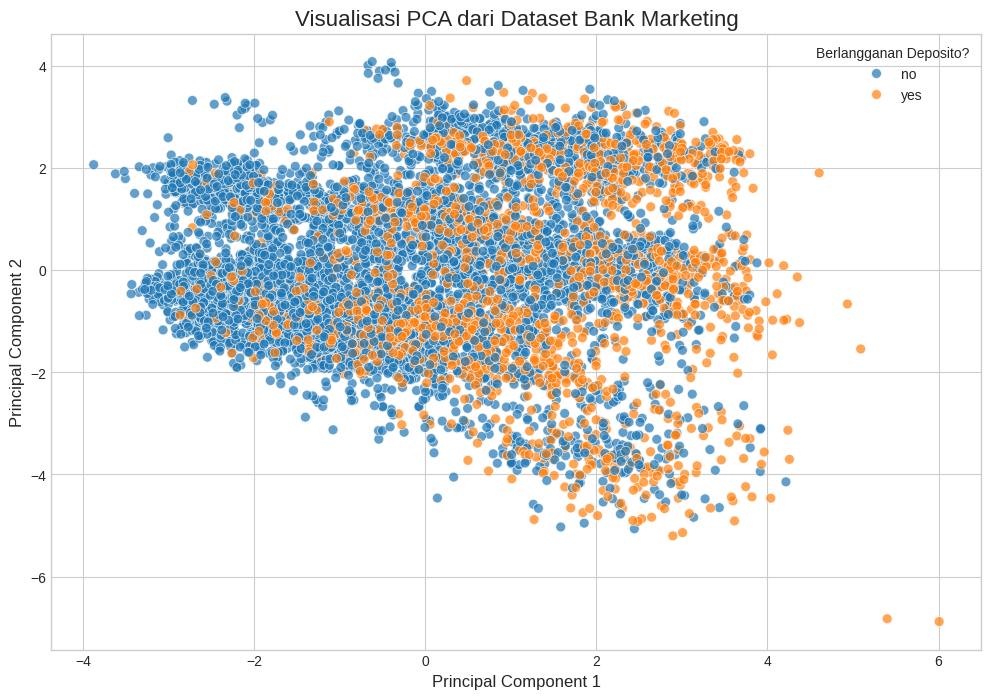


Varians yang dijelaskan oleh Principal Component 1: 7.81%
Varians yang dijelaskan oleh Principal Component 2: 6.52%
Total varians yang dijelaskan oleh 2 komponen: 14.34%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==============================================================================
# 1. MENGAMBIL DAN MEMBERSIHKAN DATA
# ==============================================================================
# Mengambil data (kode dari sebelumnya)
bank_marketing = fetch_ucirepo(id=222)
X_features = bank_marketing.data.features
y_target = bank_marketing.data.targets

# Menggabungkan fitur dan target
df = pd.concat([X_features, y_target], axis=1)

# Menghapus baris dengan nilai NaN agar data konsisten
df.dropna(inplace=True)

# Memisahkan kembali fitur (X) dan target (y) setelah dibersihkan
X = df.drop('y', axis=1)
y = df['y']

# ==============================================================================
# 2. PREPROCESSING DATA
# ==============================================================================
# Mengubah kolom kategorikal menjadi numerik menggunakan One-Hot Encoding
X_numeric = pd.get_dummies(X, drop_first=True)

# Melakukan penskalaan (scaling) fitur. Ini WAJIB untuk PCA.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

# ==============================================================================
# 3. MENERAPKAN PCA
# ==============================================================================
# Inisialisasi PCA untuk mereduksi data menjadi 2 komponen utama
pca = PCA(n_components=2)

# Fit dan transform data yang sudah di-scaling
principal_components = pca.fit_transform(X_scaled)

# Membuat DataFrame baru dari hasil komponen utama
pca_df = pd.DataFrame(data=principal_components,
                        columns=['Principal Component 1', 'Principal Component 2'])

# Menambahkan kembali kolom target ke DataFrame PCA untuk pewarnaan plot
# Pastikan untuk mereset index agar penggabungan berjalan lancar
pca_df['target'] = y.reset_index(drop=True)

# ==============================================================================
# 4. VISUALISASI HASIL PCA
# ==============================================================================
print("Membuat visualisasi PCA...")

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 8))

# Membuat scatter plot dengan Seaborn
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='target',       # Memberi warna berdasarkan nilai target ('yes' atau 'no')
    data=pca_df,
    alpha=0.7,          # Transparansi titik
    s=50                # Ukuran titik
)

# Menambahkan judul dan label
plt.title('Visualisasi PCA dari Dataset Bank Marketing', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Berlangganan Deposito?')
plt.show()

# ==============================================================================
# 5. (OPSIONAL) MELIHAT VARIANS YANG DIJELASKAN
# ==============================================================================
explained_variance = pca.explained_variance_ratio_
print(f"\nVarians yang dijelaskan oleh Principal Component 1: {explained_variance[0]:.2%}")
print(f"Varians yang dijelaskan oleh Principal Component 2: {explained_variance[1]:.2%}")
print(f"Total varians yang dijelaskan oleh 2 komponen: {np.sum(explained_variance):.2%}")

## Membersihkan data dan menghapus outlier dengan LOF

Proses ini adalah salah satu langkah paling krusial dalam persiapan data (*data preprocessing*). Tujuannya adalah untuk memastikan kualitas data sebelum dimasukkan ke dalam model *machine learning*. Prinsip utamanya adalah **"Garbage In, Garbage Out"**—jika data yang masuk buruk, maka hasil modelnya juga akan buruk.

Proses ini terdiri dari dua bagian utama: menangani nilai yang hilang dan menangani data anomali (*outlier*).

---
### 🧹 Bagian 1: Membersihkan Data (Menangani *Missing Values*)

*Missing values* (sering direpresentasikan sebagai `NaN` atau `NULL`) adalah "lubang" dalam dataset Anda. Mereka bisa muncul karena berbagai alasan, seperti kesalahan input, data tidak tercatat, atau kegagalan sensor.

#### **Mengapa ini masalah?**
Banyak algoritma *machine learning* tidak dapat bekerja jika ada nilai yang hilang dalam data. Selain itu, *missing values* dapat merusak analisis statistik dan mengurangi kualitas model.

#### **Strategi Umum:**
1.  **Penghapusan (Deletion):** Ini adalah metode paling sederhana. Anda menghapus seluruh **baris** (`df.dropna()`) yang memiliki setidaknya satu nilai `NaN`.
    * **Kelebihan:** Cepat dan mudah.
    * **Kekurangan:** Anda bisa kehilangan banyak informasi berharga, terutama jika banyak baris yang memiliki nilai `NaN`.
2.  **Imputasi (Imputation):** Ini adalah metode mengisi nilai yang hilang dengan nilai statistik.
    * Untuk data numerik: Diisi dengan **rata-rata** (*mean*), **nilai tengah** (*median*), atau nilai tertentu seperti nol.
    * Untuk data kategorikal: Diisi dengan **modus** (nilai yang paling sering muncul).
    * **Kelebihan:** Anda tidak kehilangan data.
    * **Kekurangan:** Dapat memasukkan bias ke dalam data jika tidak dilakukan dengan hati-hati.

---
### 🕵️‍♂️ Bagian 2: Menghapus Outlier dengan LOF

#### **Apa itu Outlier?**
**Outlier** adalah titik data yang berbeda secara signifikan dari pengamatan lainnya. Bayangkan Anda memiliki data tinggi badan sekelompok siswa SD, dan salah satu datanya adalah "250 cm". Data ini adalah *outlier*.



#### **Mengapa ini masalah?**
*Outlier* dapat secara drastis memengaruhi perhitungan statistik (seperti rata-rata) dan "menarik" garis regresi atau batas keputusan model ke arah yang salah, sehingga menurunkan akurasi dan keandalan model.

#### **Apa itu LOF (Local Outlier Factor)?**
**Local Outlier Factor (LOF)** adalah algoritma cerdas untuk mendeteksi *outlier*. Berbeda dari metode statistik sederhana, LOF tidak hanya melihat seberapa "jauh" sebuah titik, tetapi juga seberapa **"terisolasi"** titik tersebut dibandingkan dengan **tetangga lokalnya**.

**Analogi Sederhana:** 🏡
* Bayangkan sebuah desa yang padat penduduk. Sebuah rumah yang dibangun 5 km di luar desa jelas merupakan *outlier*.
* Sekarang bayangkan sebuah area di mana rumah-rumah berjarak 1 km satu sama lain. Jika ada satu rumah yang berjarak 5 km dari tetangga terdekatnya di area tersebut, rumah itu dianggap aneh **secara lokal**, meskipun jaraknya ke pusat desa mungkin tidak terlalu jauh.

LOF sangat baik dalam menemukan *outlier* jenis kedua ini.

#### **🛠️ Cara Kerja LOF (Secara Ringkas):**
1.  **Temukan Tetangga:** Untuk setiap titik data, LOF mencari sejumlah `k` tetangga terdekatnya.
2.  **Hitung Kepadatan Lokal:** Algoritma mengukur seberapa "padat" lingkungan di sekitar setiap titik. Jika tetangganya sangat dekat, kepadatannya tinggi.
3.  **Bandingkan Kepadatan:** Kepadatan setiap titik kemudian dibandingkan dengan kepadatan rata-rata tetangganya.
4.  **Hitung Skor LOF:**
    * Jika kepadatan sebuah titik **sama** dengan kepadatan tetangganya, skor LOF-nya sekitar **1** (dianggap normal atau *inlier*).
    * Jika kepadatan sebuah titik **jauh lebih rendah** daripada kepadatan tetangganya (artinya titik itu berada di area yang jauh lebih "sepi" daripada lingkungannya), skor LOF-nya akan **jauh lebih besar dari 1** dan dianggap sebagai **outlier**.

#### **💻 Alur Kerja dalam Kode:**
1.  **Muat Data Mentah:** Mulai dengan DataFrame asli.
2.  **Tangani *Missing Values***: Lakukan penghapusan atau imputasi. Di kode kita, kita menggunakan `df.dropna()`.
3.  **Persiapan untuk LOF:** LOF memerlukan input numerik. Jadi, semua kolom kategorikal (seperti 'job' atau 'marital') harus diubah menjadi angka menggunakan `pd.get_dummies()`.
4.  **Terapkan LOF:**
    * Buat objek `LocalOutlierFactor()`.
    * Gunakan metode `.fit_predict()` pada data numerik. Metode ini akan menghasilkan array berisi:
        * `1` untuk data normal (*inlier*).
        * `-1` untuk data anomali (*outlier*).
5.  **Saring Data:** Gunakan hasil prediksi untuk memfilter DataFrame Anda, hanya menyimpan baris yang ditandai dengan `1`.

Hasil akhirnya adalah dataset yang jauh lebih bersih dan andal, siap untuk tahap selanjutnya seperti *feature engineering* atau pemodelan.

In [ ]:
import pandas as pd
from collections import Counter
from ucimlrepo import fetch_ucirepo
from sklearn.neighbors import LocalOutlierFactor
from imblearn.over_sampling import ADASYN

# ==============================================================================
# Bagian 1: Memuat dan Membersihkan Data
# ==============================================================================
print("--- TAHAP 1: MEMUAT DAN MEMBERSIHKAN DATA ---")

# --- Memuat Data ---
bank_marketing = fetch_ucirepo(id=222)
X_features = bank_marketing.data.features
y_target = bank_marketing.data.targets
df = pd.concat([X_features, y_target], axis=1)

print(f"\nJumlah data sebelum dibersihkan: {df.shape}")
print(f"Jumlah missing values: {df.isnull().sum().sum()}")

# --- Proses Pembersihan ---
# 1. Menghapus baris dengan missing values
df_cleaned = df.dropna()

# 2. Deteksi dan menghapus outlier menggunakan LOF
X_for_lof = df_cleaned.drop('y', axis=1)
X_numeric_lof = pd.get_dummies(X_for_lof) # Data numerik untuk LOF

lof = LocalOutlierFactor(n_jobs=-1)
outlier_predictions = lof.fit_predict(X_numeric_lof)

# Simpan hanya data inlier ke dalam variabel df_cleaned
df_cleaned = df_cleaned[outlier_predictions == 1]

print(f"Jumlah data setelah dibersihkan (final): {df_cleaned.shape}")
print("-" * 55)


--- TAHAP 1: MEMUAT DAN MEMBERSIHKAN DATA ---

Jumlah data sebelum dibersihkan: (45211, 17)
Jumlah missing values: 52124
Jumlah data setelah dibersihkan (final): (7674, 17)
-------------------------------------------------------


## Menyeimbangkan Data dengan Menggunakan ADASYN

Pada banyak kasus dunia nyata (seperti deteksi penipuan atau diagnosis medis), jumlah data untuk satu kelas jauh lebih sedikit daripada kelas lainnya (data tidak seimbang). Jika kita melatih model pada data seperti ini, model akan cenderung bias dan berkinerja buruk pada kelas minoritas. Di sinilah ADASYN berperan untuk menyeimbangkan data.

### 📘 Apa itu ADASYN (Adaptive Synthetic Sampling)?

**ADASYN** atau *Adaptive Synthetic Sampling* adalah **metode *oversampling*** yang digunakan dalam *machine learning* untuk mengatasi masalah ketidakseimbangan kelas. Caranya adalah dengan membuat data **sintetis** (data buatan) untuk kelas minoritas.

Keunikan ADASYN adalah sifatnya yang **adaptif**: ia akan membuat lebih banyak data sintetis untuk sampel minoritas yang lebih sulit dipelajari.

---

### 🎯 Tujuan ADASYN:

* **Mengatasi ketidakseimbangan kelas** dengan menambah jumlah sampel kelas minoritas.
* **Mencegah model menjadi bias** terhadap kelas mayoritas.
* **Meningkatkan kemampuan model** untuk mengenali dan memprediksi kelas minoritas.
* **Fokus pada sampel yang sulit**, yaitu sampel minoritas yang berada di perbatasan atau dikelilingi oleh sampel mayoritas.

---

### 🛠️ Cara Kerja ADASYN (Secara Ringkas):

Berikut adalah logika dan rumus utama dalam **Adaptive Synthetic Sampling (ADASYN)**.

---

### 1. **Hitung Jumlah Data Sintetis**

Pertama, tentukan berapa banyak data sintetis ($G$) yang perlu dibuat untuk menyeimbangkan kelas.

$$G = (n_{maj} - n_{min}) \times \beta$$

* $n_{maj}$: jumlah sampel kelas mayoritas.
* $n_{min}$: jumlah sampel kelas minoritas.
* $\beta$: tingkat keseimbangan yang diinginkan (biasanya $\beta=1$ untuk membuatnya seimbang penuh).

---

### 2. **Identifikasi Lingkungan Sampel**

Untuk setiap sampel kelas minoritas ($x_i$), temukan $k$ tetangga terdekatnya (*k-nearest neighbors*) dan identifikasi rasio kelas mayoritas di lingkungannya.

$$\gamma_i = \frac{\Delta_i}{k}$$

* $\Delta_i$: jumlah sampel kelas mayoritas di antara $k$ tetangga dari $x_i$.
* $\gamma_i$: rasio yang menunjukkan tingkat "kesulitan" dari sampel $x_i$. Semakin tinggi nilainya, semakin sulit sampel itu untuk dipelajari.

---

### 3. **Hitung Kepadatan Sampling**

Normalisasi rasio kesulitan ($\gamma_i$) untuk semua sampel minoritas sehingga totalnya menjadi 1. Ini akan menjadi "kepadatan" atau probabilitas sampling.

$$\hat{r}_i = \frac{\gamma_i}{\sum_{j=1}^{n_{min}} \gamma_j}$$

* $\hat{r}_i$: kepadatan sampling untuk sampel $x_i$. Sampel yang lebih "sulit" ($\gamma_i$ tinggi) akan memiliki $\hat{r}_i$ yang lebih tinggi.

---

### 4. **Buat Data Sintetis**

Buat data sintetis berdasarkan kepadatan sampling. Jumlah data yang dibuat untuk setiap sampel minoritas adalah $g_i = \hat{r}_i \times G$.

Data sintetis ($s_i$) dibuat di antara sampel minoritas ($x_i$) dan salah satu tetangga minoritasnya ($x_{zi}$).

$$s_i = x_i + (x_{zi} - x_i) \times \lambda$$

* $x_{zi}$: sampel acak dari tetangga kelas minoritas $x_i$.
* $\lambda$: angka acak antara 0 dan 1.

### 📐 Contoh:

Bayangkan Anda memiliki data deteksi email spam:

* Email Bukan Spam (mayoritas): 1000
* Email Spam (minoritas): 50

Sebuah model mungkin akan cenderung menebak semua email sebagai "Bukan Spam" karena akurasinya tetap tinggi.

...dengan ADASYN, algoritma akan:
1.  Mengidentifikasi email spam mana yang paling "mirip" dengan email bukan spam (ini adalah sampel yang sulit).
2.  Membuat lebih banyak sampel email spam sintetis di sekitar area "sulit" tersebut.
3.  Hasilnya adalah dataset baru yang lebih seimbang, misalnya 1000 Bukan Spam dan ~995 Spam.

Dengan data yang sudah seimbang ini, model dapat mempelajari pola email spam secara lebih efektif.

In [ ]:

# ==============================================================================
# Bagian 2: Menyeimbangkan Data dari Variabel df_cleaned
# ==============================================================================
print("\n--- TAHAP 2: MENYEIMBANGKAN DATA BERSIH DENGAN ADASYN ---")

# --- Memisahkan Fitur dan Target dari df_cleaned ---
X_clean = df_cleaned.drop('y', axis=1)
y_clean = df_cleaned['y']

# --- Menghitung Kelas Sebelum Penyeimbangan ---
original_counts = Counter(y_clean)
print("\nKelas pada data bersih (Sebelum ADASYN):")
print(f"  Jumlah kelas 'no' : {original_counts['no']}")
print(f"  Jumlah kelas 'yes': {original_counts['yes']}")

# --- Menerapkan ADASYN ---
X_clean_numeric = pd.get_dummies(X_clean, drop_first=True)

print("\nMenjalankan proses ADASYN...")
adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_clean_numeric, y_clean)
print("Proses ADASYN selesai.")

# --- Menghitung Kelas Setelah Penyeimbangan ---
resampled_counts = Counter(y_resampled)
print("\nKelas setelah diseimbangkan dengan ADASYN:")
print(f"  Jumlah kelas 'no' : {resampled_counts['no']}")
print(f"  Jumlah kelas 'yes': {resampled_counts['yes']}")
print("-" * 55)


--- TAHAP 2: MENYEIMBANGKAN DATA BERSIH DENGAN ADASYN ---

Kelas pada data bersih (Sebelum ADASYN):
  Jumlah kelas 'no' : 5961
  Jumlah kelas 'yes': 1713

Menjalankan proses ADASYN...
Proses ADASYN selesai.

Kelas setelah diseimbangkan dengan ADASYN:
  Jumlah kelas 'no' : 5961
  Jumlah kelas 'yes': 6123
-------------------------------------------------------


## Visualisasi data dengan menggunakan PCA pada data yang sudah seimbang


Menerapkan PCA pada data yang sudah seimbang...
Membuat visualisasi PCA dari data seimbang...


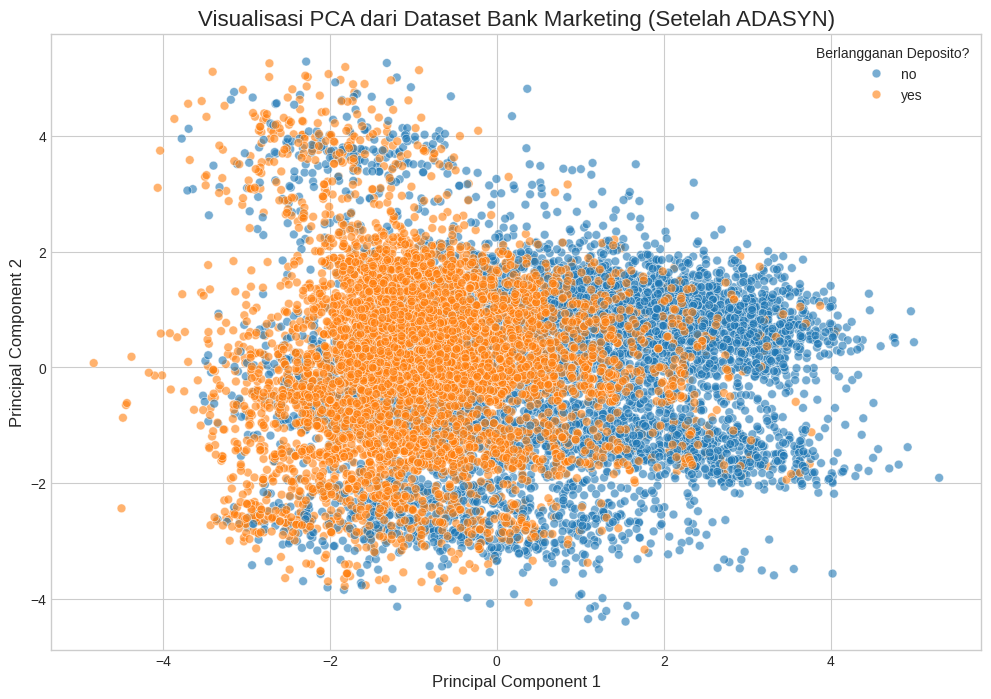

In [ ]:
# ==============================================================================
# 2. MENERAPKAN PCA PADA DATA YANG SUDAH SEIMBANG
# ==============================================================================
# Impor library yang diperlukan untuk PCA dan Visualisasi
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\nMenerapkan PCA pada data yang sudah seimbang...")

# Langkah 2.1: Melakukan penskalaan (scaling) pada data yang sudah di-resample
# Ini penting untuk performa PCA yang optimal
scaler = StandardScaler()
X_scaled_resampled = scaler.fit_transform(X_resampled) # Pastikan X_resampled sudah ada

# Langkah 2.2: Inisialisasi dan terapkan PCA untuk 2 komponen
pca = PCA(n_components=2)
principal_components_resampled = pca.fit_transform(X_scaled_resampled)

# Langkah 2.3: Membuat DataFrame baru dari hasil PCA
pca_df_resampled = pd.DataFrame(data=principal_components_resampled,
                                  columns=['Principal Component 1', 'Principal Component 2'])

# Langkah 2.4: Menambahkan target yang sudah seimbang ke DataFrame PCA
pca_df_resampled['target'] = y_resampled # Pastikan y_resampled sudah ada

# ==============================================================================
# 3. VISUALISASI HASIL PCA
# ==============================================================================
print("Membuat visualisasi PCA dari data seimbang...")

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 8))

# Membuat scatter plot dengan Seaborn
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='target',       # Memberi warna berdasarkan target ('yes' atau 'no')
    data=pca_df_resampled,
    alpha=0.6,          # Transparansi agar tumpukan titik terlihat
    s=40
)

# Menambahkan judul dan label
plt.title('Visualisasi PCA dari Dataset Bank Marketing (Setelah ADASYN)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Berlangganan Deposito?')
plt.show()

## Melakukan modeling dengan Naive Bayes dan SVM
Tentu, mari kita bahas cara melakukan *ensemble learning* dengan menggabungkan dua model yang sangat berbeda: **Naive Bayes** dan **Support Vector Machine (SVM)**.

## Modeling Ensemble Learning dengan Naive Bayes dan SVM

Menggabungkan Naive Bayes dan SVM adalah contoh bagus dari *ensemble learning* karena keduanya memiliki cara kerja yang fundamentally berbeda. Tujuannya adalah untuk menciptakan satu "meta-model" yang lebih kuat dengan memanfaatkan kelebihan masing-masing.

  * **Naive Bayes** adalah model **probabilistik**. Ia membuat prediksi berdasarkan probabilitas (peluang) kemunculan fitur pada setiap kelas.
  * **SVM** adalah model **geometris**. Ia bekerja dengan mencari "jalan" atau *hyperplane* terbaik yang memisahkan data antar kelas.

Dengan menggabungkan keduanya, kita berharap model gabungan ini bisa lebih akurat dan stabil.

-----

### 🎯 Tujuan Menggabungkan Naive Bayes dan SVM

  * **Meningkatkan Akurasi:** Model gabungan seringkali lebih akurat daripada masing-masing model secara individu.
  * **Meningkatkan Stabilitas:** Mengurangi kemungkinan *overfitting* dan membuat prediksi lebih konsisten.
  * **Memanfaatkan Kekuatan Berbeda:** Naive Bayes cepat dan bagus dalam menangani fitur yang tidak relevan, sementara SVM kuat dalam menemukan hubungan non-linear yang kompleks (dengan kernel). Ensemble ini bisa mendapatkan yang terbaik dari "dua dunia".

-----

### 🗳️ Metode Utama: Voting Classifier

Cara paling umum dan mudah untuk menggabungkan model yang berbeda seperti Naive Bayes dan SVM adalah dengan menggunakan **Voting Classifier**.

**Voting Classifier** bekerja seperti sistem demokrasi. Beberapa model (disebut *base models* atau *estimators*) "memberikan suara" (*vote*) untuk prediksi akhir. Model yang menerima suara mayoritas akan menjadi keputusan akhir.

**Analogi Sederhana:** 🧑‍⚕️
Bayangkan Anda meminta diagnosis dari dua dokter berbeda untuk suatu penyakit:

1.  **Dokter A (Naive Bayes):** Seorang dokter umum yang cepat menganalisis gejala berdasarkan data statistik dan probabilitas dari ribuan pasien sebelumnya.
2.  **Dokter B (SVM):** Seorang dokter spesialis yang dengan teliti mencari "garis pemisah" yang jelas antara gejala penyakit A dan B.

**Voting Classifier** bertindak sebagai dewan medis yang mengambil keputusan akhir berdasarkan masukan dari kedua dokter tersebut, sehingga hasilnya lebih dapat diandalkan.

#### **Jenis-Jenis Voting:**

1.  **Hard Voting (Suara Mayoritas Mutlak)**

      * Setiap model memberikan satu suara untuk satu kelas.
      * Kelas dengan jumlah suara terbanyak akan menjadi prediksi akhir.
      * Contoh: Naive Bayes memprediksi "Kelas A", SVM memprediksi "Kelas A". Hasilnya adalah "Kelas A". Jika prediksinya berbeda, dan ada model ketiga, maka kelas yang dipilih oleh dua dari tiga model akan menang.

2.  **Soft Voting (Berdasarkan Tingkat Keyakinan)**

      * Metode ini seringkali lebih unggul.
      * Setiap model tidak hanya memprediksi kelas, tetapi juga memberikan **probabilitas** atau tingkat keyakinan untuk setiap kelas (misal: "Saya 80% yakin ini Kelas A, dan 20% Kelas B").
      * *Voting Classifier* akan merata-ratakan probabilitas dari semua model, dan kelas dengan rata-rata probabilitas tertinggi akan menjadi prediksi akhir.
      * **Penting:** Untuk menggunakan *soft voting* dengan SVM, Anda harus mengaturnya dengan `SVC(probability=True)`.

-----

### 💻 Alur Kerja Implementasi (dengan Scikit-Learn)

Berikut adalah langkah-langkah umum untuk menerapkannya dalam kode:

1.  **Persiapan Data:**

      * Bersihkan data Anda (*missing values*, *outliers*).
      * Lakukan *scaling* pada fitur jika diperlukan (sangat direkomendasikan untuk SVM).
      * Bagi data menjadi set pelatihan dan set pengujian (`train_test_split`).

2.  **Inisialisasi Model-Model Dasar:**

      * Buat objek untuk setiap model yang ingin Anda gabungkan.

    <!-- end list -->

    ```python
    from sklearn.naive_bayes import GaussianNB
    from sklearn.svm import SVC

    model_nb = GaussianNB()
    model_svm = SVC(probability=True, random_state=42) # probability=True untuk soft voting
    ```

3.  **Buat Ensemble Model (Voting Classifier):**

      * Impor `VotingClassifier` dari `sklearn.ensemble`.
      * Buat daftar (*list*) yang berisi *tuple* dari nama model dan objek modelnya.
      * Inisialisasi `VotingClassifier` dengan daftar tersebut dan tentukan jenis voting (`'hard'` atau `'soft'`).

    <!-- end list -->

    ```python
    from sklearn.ensemble import VotingClassifier

    # Buat daftar estimators
    estimators = [('naive_bayes', model_nb), ('svm', model_svm)]

    # Buat ensemble model dengan soft voting
    ensemble_model = VotingClassifier(estimators=estimators, voting='soft')
    ```

4.  **Latih Ensemble Model:**

      * Latih `ensemble_model` seperti Anda melatih model biasa, menggunakan data pelatihan.

    <!-- end list -->

    ```python
    # Latih model pada data training
    ensemble_model.fit(X_train, y_train)
    ```

    Scikit-learn secara otomatis akan melatih `model_nb` dan `model_svm` di dalamnya.

5.  **Evaluasi Model:**

      * Lakukan prediksi pada data pengujian dan evaluasi performanya menggunakan metrik seperti akurasi, presisi, recall, atau `classification_report`.

    <!-- end list -->

    ```python
    from sklearn.metrics import accuracy_score

    # Lakukan prediksi
    y_pred = ensemble_model.predict(X_test)

    # Cek akurasi
    print(f"Akurasi Ensemble Model: {accuracy_score(y_test, y_pred)}")
    ```

### ✨ Kesimpulan

Menggabungkan Naive Bayes dan SVM melalui **Voting Classifier** adalah strategi *ensemble* yang efektif karena memanfaatkan **keragaman** kedua model. Keragaman ini seringkali menghasilkan model gabungan yang lebih kuat dan generalis, yang tidak hanya berkinerja baik pada data pelatihan tetapi juga pada data baru yang belum pernah dilihat.

--- MEMBUAT DAN MELATIH MODEL ENSEMBLE ---
Model selesai dilatih.

--- HASIL EVALUASI MODEL ---
Akurasi Model Ensemble: 0.7981

Classification Report:
              precision    recall  f1-score   support

          no       0.91      0.82      0.86      1789
         yes       0.54      0.71      0.61       514

    accuracy                           0.80      2303
   macro avg       0.72      0.77      0.74      2303
weighted avg       0.83      0.80      0.81      2303


Confusion Matrix:


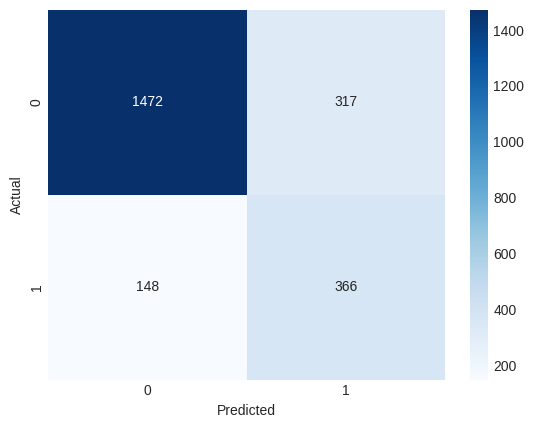

In [22]:
import pandas as pd
from collections import Counter

# Impor untuk pemodelan
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

# Impor untuk evaluasi
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PERSIAPAN DATA (Menggunakan data bersih dari tahap sebelumnya)
# ==============================================================================
# Anggap saja 'df_cleaned' adalah variabel berisi data bersih Anda.
# Jika Anda menjalankannya dari file, muat dulu:
# df_cleaned = pd.read_csv('bank_marketing_cleaned.csv')

# Memisahkan fitur (X) dan target (y)
X = df_cleaned.drop('y', axis=1)
y = df_cleaned['y']

# Mengubah data kategorikal menjadi numerik
X_numeric = pd.get_dummies(X, drop_first=True)

# Membagi data menjadi data latih (train) dan data uji (test)
# Ini WAJIB untuk evaluasi model yang valid.
X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.3, random_state=42, stratify=y)

# Penskalaan data (Sangat penting untuk SVM)
# Kita 'fit' scaler HANYA pada data latih untuk menghindari kebocoran data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Gunakan scaler yang sama untuk data test

# ==============================================================================
# 2. MEMBUAT MODEL ENSEMBLE
# ==============================================================================
print("--- MEMBUAT DAN MELATIH MODEL ENSEMBLE ---")

# Inisialisasi model 1: Gaussian Naive Bayes
clf1 = GaussianNB()

# Inisialisasi model 2: Support Vector Machine (SVM)
# probability=True diperlukan untuk 'soft voting'
clf2 = SVC(gamma='auto', probability=True)

# Membuat Ensemble dengan VotingClassifier
# 'estimators' berisi daftar model yang akan digabungkan
# 'voting='soft'' berarti kita menggunakan rata-rata probabilitas
eclf = VotingClassifier(
    estimators=[('gnb', clf1), ('svc', clf2)],
    voting='soft'
)

# Melatih model ensemble pada data latih yang sudah diskalakan
eclf = eclf.fit(X_train_scaled, y_train)
print("Model selesai dilatih.")

# ==============================================================================
# 3. EVALUASI MODEL
# ==============================================================================
print("\n--- HASIL EVALUASI MODEL ---")
# Melakukan prediksi pada data uji
y_pred = eclf.predict(X_test_scaled)

# Menghitung dan menampilkan akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model Ensemble: {accuracy:.4f}")

# Menampilkan classification report (presisi, recall, f1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Menampilkan Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Membuat Model esemble learning dengan menggunakan SVM dan Naive Bayes

In [23]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Impor semua komponen yang diperlukan dari scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report

# ==============================================================================
# 1. PERSIAPAN DATA
# ==============================================================================
# Mengambil dataset Bank Marketing
bank_marketing = fetch_ucirepo(id=222)
X_features = bank_marketing.data.features
y_target = bank_marketing.data.targets

# Menggabungkan fitur dan target, lalu membersihkan data dari nilai NaN
df = pd.concat([X_features, y_target], axis=1)
df.dropna(inplace=True)

# Memisahkan fitur (X) dan target (y)
X = df.drop('y', axis=1)
y = df['y']

# Mengubah kolom kategorikal menjadi numerik menggunakan One-Hot Encoding
X_numeric = pd.get_dummies(X, drop_first=True)

# Membagi data menjadi 80% data latih dan 20% data uji
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================================================================
# 2. MEMBUAT MODEL ENSEMBLE
# ==============================================================================
# Inisialisasi model-model dasar
# Naive Bayes tidak memerlukan scaling
model_nb = GaussianNB()

# SVM sangat sensitif terhadap skala fitur, jadi kita gabungkan dengan StandardScaler
# menggunakan pipeline. 'probability=True' wajib untuk 'soft' voting.
model_svm = make_pipeline(
    StandardScaler(),
    SVC(probability=True, random_state=42)
)

# Buat daftar estimators (nama, model) untuk VotingClassifier
estimators = [
    ('naive_bayes', model_nb),
    ('svm', model_svm)
]

# Buat model ensemble dengan metode 'soft' voting
# Soft voting seringkali memberikan hasil yang lebih baik
ensemble_model = VotingClassifier(
    estimators=estimators,
    voting='soft'
)

# ==============================================================================
# 3. MELATIH DAN MENGEVALUASI MODEL
# ==============================================================================
print("Melatih model ensemble (Voting Classifier)...")
# Melatih model ensemble pada data latih
ensemble_model.fit(X_train, y_train)
print("Pelatihan selesai.")

# Melakukan prediksi pada data uji
print("\nMelakukan prediksi pada data uji...")
y_pred = ensemble_model.predict(X_test)

# Mengevaluasi performa model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("\n--- HASIL EVALUASI MODEL ENSEMBLE ---")
print(f"Akurasi Model: {accuracy:.4f}")
print("\nLaporan Klasifikasi:")
print(report)
print("-----------------------------------------")

Melatih model ensemble (Voting Classifier)...
Pelatihan selesai.

Melakukan prediksi pada data uji...

--- HASIL EVALUASI MODEL ENSEMBLE ---
Akurasi Model: 0.8031

Laporan Klasifikasi:
              precision    recall  f1-score   support

          no       0.91      0.83      0.87      1212
         yes       0.55      0.73      0.63       357

    accuracy                           0.80      1569
   macro avg       0.73      0.78      0.75      1569
weighted avg       0.83      0.80      0.81      1569

-----------------------------------------


### Membuat Model Esemble Learning dengam data yang belum bersih dan tanpa penyeimbangan

In [24]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Impor semua komponen yang diperlukan
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# ==============================================================================
# 1. PERSIAPAN DATA (TANPA PEMBERSIHAN MANUAL)
# ==============================================================================
# Mengambil dataset Bank Marketing
bank_marketing = fetch_ucirepo(id=222)
X = bank_marketing.data.features
y = bank_marketing.data.targets['y'] # Langsung ambil kolom target

# Membagi data menjadi 80% data latih dan 20% data uji
# Data ini masih mentah, tidak seimbang, dan memiliki missing values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================================================================
# 2. MEMBUAT PIPELINE PREPROCESSING
# ==============================================================================
# Pipeline ini akan menangani data mentah secara otomatis

# Identifikasi kolom numerik dan kategorikal
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Membuat pipeline untuk data numerik:
# 1. Isi missing values dengan nilai median
# 2. Lakukan scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Membuat pipeline untuk data kategorikal:
# 1. Isi missing values dengan nilai yang paling sering muncul ('most_frequent')
# 2. Lakukan One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Gabungkan kedua pipeline di atas dengan ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# ==============================================================================
# 3. MEMBUAT MODEL ENSEMBLE
# ==============================================================================
# Inisialisasi model-model dasar
model_nb = GaussianNB()
model_svm = SVC(probability=True, random_state=42)

# Buat daftar estimators
estimators = [
    ('naive_bayes', model_nb),
    ('svm', model_svm)
]

# Buat model ensemble dengan 'soft' voting
ensemble_model = VotingClassifier(
    estimators=estimators,
    voting='soft'
)

# ==============================================================================
# 4. MENGGABUNGKAN PREPROCESSING DAN MODEL ENSEMBLE
# ==============================================================================
# Buat pipeline akhir yang menyatukan preprocessor dan model ensemble
# Ini memungkinkan kita melatih semuanya dalam satu langkah pada data mentah
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', ensemble_model)
])

# ==============================================================================
# 5. MELATIH DAN MENGEVALUASI MODEL
# ==============================================================================
print("Melatih model ensemble pada data mentah (belum bersih dan tidak seimbang)...")
# Melatih pipeline pada data latih mentah
full_pipeline.fit(X_train, y_train)
print("Pelatihan selesai.")

# Melakukan prediksi pada data uji
print("\nMelakukan prediksi pada data uji...")
y_pred = full_pipeline.predict(X_test)

# Mengevaluasi performa model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=0)

print("\n--- HASIL EVALUASI MODEL ENSEMBLE (DATA MENTAH) ---")
print(f"Akurasi Model: {accuracy:.4f}")
print("\nLaporan Klasifikasi:")
print(report)
print("-----------------------------------------------------")

Melatih model ensemble pada data mentah (belum bersih dan tidak seimbang)...
Pelatihan selesai.

Melakukan prediksi pada data uji...

--- HASIL EVALUASI MODEL ENSEMBLE (DATA MENTAH) ---
Akurasi Model: 0.8664

Laporan Klasifikasi:
              precision    recall  f1-score   support

          no       0.93      0.92      0.92      7985
         yes       0.44      0.48      0.46      1058

    accuracy                           0.87      9043
   macro avg       0.68      0.70      0.69      9043
weighted avg       0.87      0.87      0.87      9043

-----------------------------------------------------


Tentu, ini adalah kesimpulan dari ketiga percobaan pemodelan Anda, yang disajikan dalam bentuk tabel perbandingan dan penjelasan.

### Perbandingan Hasil Tiga Model Ensemble

Tabel berikut merangkum metrik kinerja utama dari ketiga percobaan. Fokus utama diberikan pada performa terhadap kelas minoritas ('yes'), karena ini adalah indikator sebenarnya dari kegunaan model pada data yang tidak seimbang.

| Model / Percobaan | Akurasi Keseluruhan | Precision (Kelas 'yes') | Recall (Kelas 'yes') | F1-Score (Kelas 'yes') |
| :--- | :---: | :---: | :---: | :---: |
| **Ensemble (Data Bersih & Seimbang) - Set 1** | 79.81% | 0.54 | **0.71** | **0.61** |
| **Ensemble (Data Bersih & Seimbang) - Set 2** | 80.31% | 0.55 | **0.73** | **0.63** |
| **Ensemble (Data Mentah & Tidak Seimbang)** | **86.64%** | 0.44 | 0.48 | 0.46 |

---
## Kesimpulan

Berdasarkan perbandingan di atas, kesimpulan utamanya adalah:

1.  **Akurasi Tinggi Bukan Jaminan (Paradoks Akurasi)**
    Model yang dilatih pada **data mentah** menunjukkan **akurasi tertinggi (86.64%)**, namun sebenarnya ini adalah **model yang paling buruk**. Akurasi ini bersifat ilusi karena model hanya pandai menebak kelas mayoritas ('no') dan hampir gagal total dalam mengenali kelas minoritas ('yes'), yang dibuktikan dengan **Recall (0.48)** dan **F1-Score (0.46)** yang sangat rendah.

2.  **Pentingnya Data Bersih dan Seimbang**
    Dua model pertama, yang dilatih pada **data yang sudah dibersihkan dan diseimbangkan**, menunjukkan akurasi keseluruhan yang lebih rendah. Namun, model-model ini **jauh lebih unggul** dalam tugas yang sebenarnya. Metrik **Recall** mereka sangat tinggi **(0.71 dan 0.73)**. Artinya, model ini berhasil **menemukan lebih dari 70%** dari semua pelanggan yang seharusnya masuk kategori 'yes', menjadikannya jauh lebih berguna secara praktis.

3.  **Recall adalah Metrik Kunci**
    Dalam kasus bisnis seperti ini (mencari pelanggan potensial), **Recall** seringkali menjadi metrik yang paling penting. Anda ingin "menangkap" sebanyak mungkin pelanggan 'yes', bahkan jika ada beberapa tebakan yang salah (*false positive*). Dua model pertama berhasil melakukan ini, sementara model pada data mentah gagal.

Secara keseluruhan, **percobaan pada data yang bersih dan seimbang jelas merupakan pemenangnya**. Meskipun akurasinya lebih rendah, model-model tersebut memberikan nilai prediksi yang nyata dan dapat diandalkan untuk menemukan kelas minoritas yang menjadi target utama.